In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf
from zoneinfo import ZoneInfo

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

SYDNEY = ZoneInfo("Australia/Sydney")
CDT = ZoneInfo("America/Chicago")

CONTRACT_MULTIPLIER = 100_000  # CME AUD option on futures is based on 100,000 AUD


In [2]:
# =========================
# USER INPUT SECTION
# =========================

ENTRY_TIME_SYDNEY = pd.Timestamp("2026-05-04 10:30", tz=SYDNEY)

# You only told me the close date, not the exact close time.
# Change this to the real manual exit time from your trading log.
EXIT_TIME_SYDNEY = pd.Timestamp("2026-05-06 15:30", tz=SYDNEY)

# Set this to the actual option expiry used in the simulator.
# For the dashboard, this is editable.
EXPIRY_TIME_SYDNEY = pd.Timestamp("2026-05-08 17:00", tz=SYDNEY)

# Replace entry_price and exit_price with your actual fills from CME.
# Current values are placeholders for the notebook to run.
legs = pd.DataFrame([
    {
        "leg": "Long 0.7200 call",
        "strike": 0.7200,
        "qty": 1,
        "entry_action": "Buy",
        "entry_time_sydney": "2026-05-04 10:30",
        "entry_price": 0.0032,
        "exit_action": "Sell",
        "exit_time_sydney": "2026-05-06 15:30",
        "exit_price": 0.0067,
    },
    {
        "leg": "Short 2x 0.7275 calls",
        "strike": 0.7275,
        "qty": -2,
        "entry_action": "Sell",
        "entry_time_sydney": "2026-05-04 10:31",
        "entry_price": 0.0011,
        "exit_action": "Buy back",
        "exit_time_sydney": "2026-05-06 15:31",
        "exit_price": 0.0019,
    },
    {
        "leg": "Long 0.7350 call",
        "strike": 0.7350,
        "qty": 1,
        "entry_action": "Buy",
        "entry_time_sydney": "2026-05-04 10:32",
        "entry_price": 0.0003,
        "exit_action": "Sell",
        "exit_time_sydney": "2026-05-06 15:32",
        "exit_price": 0.00005,
    },
])

legs["entry_time_sydney"] = pd.to_datetime(legs["entry_time_sydney"]).dt.tz_localize(SYDNEY)
legs["exit_time_sydney"] = pd.to_datetime(legs["exit_time_sydney"]).dt.tz_localize(SYDNEY)

legs["entry_time_cdt"] = legs["entry_time_sydney"].dt.tz_convert(CDT)
legs["exit_time_cdt"] = legs["exit_time_sydney"].dt.tz_convert(CDT)

legs


,leg,strike,qty,entry_action,entry_time_sydney,entry_price,exit_action,exit_time_sydney,exit_price,entry_time_cdt,exit_time_cdt
0,Long 0.7200 call,0.720000,1,Buy,2026-05-04 10:30:00+10:00,0.003200,Sell,2026-05-06 15:30:00+10:00,0.006700,2026-05-03 19:30:00-05:00,2026-05-06 00:30:00-05:00
1,Short 2x 0.7275 calls,0.727500,-2,Sell,2026-05-04 10:31:00+10:00,0.001100,Buy back,2026-05-06 15:31:00+10:00,0.001900,2026-05-03 19:31:00-05:00,2026-05-06 00:31:00-05:00
2,Long 0.7350 call,0.735000,1,Buy,2026-05-04 10:32:00+10:00,0.000300,Sell,2026-05-06 15:32:00+10:00,0.000050,2026-05-03 19:32:00-05:00,2026-05-06 00:32:00-05:00


In [3]:
def calculate_realized_pnl(legs_df: pd.DataFrame, multiplier: float = CONTRACT_MULTIPLIER) -> pd.DataFrame:
    out = legs_df.copy()
    out["premium_paid_at_entry_usd"] = np.where(
        out["qty"] > 0,
        out["qty"] * out["entry_price"] * multiplier,
        0.0
    )
    out["premium_received_at_entry_usd"] = np.where(
        out["qty"] < 0,
        abs(out["qty"]) * out["entry_price"] * multiplier,
        0.0
    )
    out["pnl_usd"] = out["qty"] * (out["exit_price"] - out["entry_price"]) * multiplier
    out["pnl_per_contract_usd"] = (out["exit_price"] - out["entry_price"]) * multiplier
    return out

realized = calculate_realized_pnl(legs)

summary = pd.DataFrame({
    "Metric": [
        "Total entry debit, USD",
        "Total realized PnL, USD",
        "Gross premium paid, USD",
        "Gross premium received, USD",
        "Return on net debit"
    ],
    "Value": [
        (legs["qty"] * legs["entry_price"] * CONTRACT_MULTIPLIER).sum(),
        realized["pnl_usd"].sum(),
        realized["premium_paid_at_entry_usd"].sum(),
        realized["premium_received_at_entry_usd"].sum(),
        realized["pnl_usd"].sum() / abs((legs["qty"] * legs["entry_price"] * CONTRACT_MULTIPLIER).sum())
    ]
})

display(realized[[
    "leg", "qty", "strike", "entry_price", "exit_price",
    "premium_paid_at_entry_usd", "premium_received_at_entry_usd", "pnl_usd"
]])

display(summary)


,leg,qty,strike,entry_price,exit_price,premium_paid_at_entry_usd,premium_received_at_entry_usd,pnl_usd
0,Long 0.7200 call,1,0.720000,0.003200,0.006700,320.000000,0.000000,350.000000
1,Short 2x 0.7275 calls,-2,0.727500,0.001100,0.001900,0.000000,220.000000,-160.000000
2,Long 0.7350 call,1,0.735000,0.000300,0.000050,30.000000,0.000000,-25.000000


,Metric,Value
0,"Total entry debit, USD",130.000000
1,"Total realized PnL, USD",165.000000
2,"Gross premium paid, USD",350.000000
3,"Gross premium received, USD",220.000000
4,Return on net debit,1.269231


In [4]:
entry_rows = []
exit_rows = []

for _, row in legs.iterrows():
    entry_rows.append({
        "Date / time Sydney": row["entry_time_sydney"].strftime("%d %b %Y, %H:%M"),
        "Date / time CDT": row["entry_time_cdt"].strftime("%d %b %Y, %H:%M"),
        "Action": "Entered",
        "Instrument": "CME AUD/USD option on 6A futures",
        "Position": f'{row["entry_action"]} {abs(row["qty"])}x {row["strike"]:.4f} call',
        "Price": row["entry_price"],
    })

    exit_rows.append({
        "Date / time Sydney": row["exit_time_sydney"].strftime("%d %b %Y, %H:%M"),
        "Date / time CDT": row["exit_time_cdt"].strftime("%d %b %Y, %H:%M"),
        "Action": "Manually closed",
        "Instrument": "CME AUD/USD option on 6A futures",
        "Position": f'{row["exit_action"]} {abs(row["qty"])}x {row["strike"]:.4f} call',
        "Price": row["exit_price"],
    })

trading_log = pd.DataFrame(entry_rows + exit_rows)
trading_log


,Date / time Sydney,Date / time CDT,Action,Instrument,Position,Price
0,"04 May 2026, 10:30","03 May 2026, 19:30",Entered,CME AUD/USD option on 6A futures,Buy 1x 0.7200 call,0.003200
1,"04 May 2026, 10:31","03 May 2026, 19:31",Entered,CME AUD/USD option on 6A futures,Sell 2x 0.7275 call,0.001100
2,"04 May 2026, 10:32","03 May 2026, 19:32",Entered,CME AUD/USD option on 6A futures,Buy 1x 0.7350 call,0.000300
3,"06 May 2026, 15:30","06 May 2026, 00:30",Manually closed,CME AUD/USD option on 6A futures,Sell 1x 0.7200 call,0.006700
4,"06 May 2026, 15:31","06 May 2026, 00:31",Manually closed,CME AUD/USD option on 6A futures,Buy back 2x 0.7275 call,0.001900
5,"06 May 2026, 15:32","06 May 2026, 00:32",Manually closed,CME AUD/USD option on 6A futures,Sell 1x 0.7350 call,0.000050


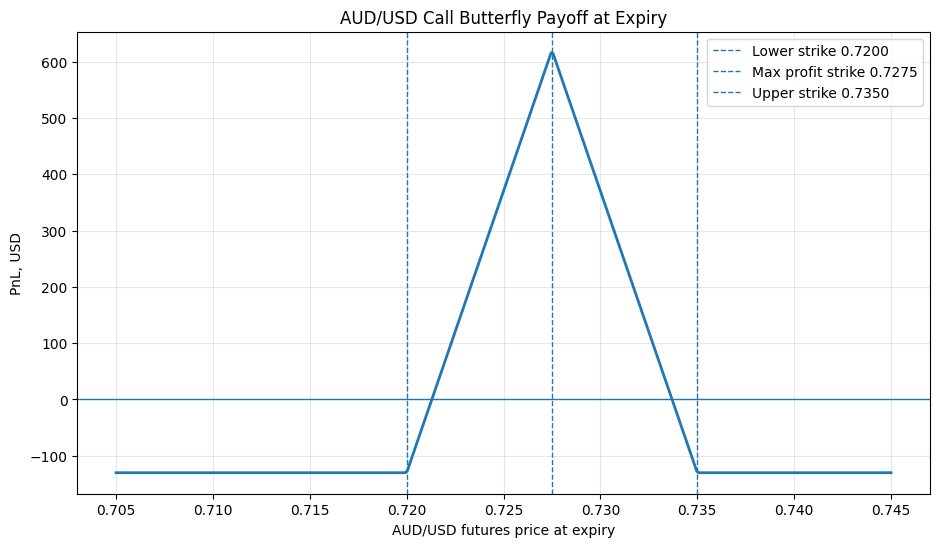

Net debit paid: 0.001300 points = $130.00
Maximum intrinsic value before premium: 750.00 USD
Maximum profit after premium: $620.00
Maximum loss: $130.00
Lower breakeven: 0.721300
Upper breakeven: 0.733700


In [5]:
def call_payoff(S, K):
    return np.maximum(S - K, 0.0)

lower_K = 0.7200
middle_K = 0.7275
upper_K = 0.7350

net_debit_points = (legs["qty"] * legs["entry_price"]).sum()
net_debit_usd = net_debit_points * CONTRACT_MULTIPLIER

S_grid = np.linspace(0.7050, 0.7450, 400)

payoff_points = (
    call_payoff(S_grid, lower_K)
    - 2 * call_payoff(S_grid, middle_K)
    + call_payoff(S_grid, upper_K)
    - net_debit_points
)

payoff_usd = payoff_points * CONTRACT_MULTIPLIER

plt.figure(figsize=(11, 6))
plt.plot(S_grid, payoff_usd, linewidth=2)
plt.axhline(0, linewidth=1)
plt.axvline(lower_K, linestyle="--", linewidth=1, label="Lower strike 0.7200")
plt.axvline(middle_K, linestyle="--", linewidth=1, label="Max profit strike 0.7275")
plt.axvline(upper_K, linestyle="--", linewidth=1, label="Upper strike 0.7350")
plt.title("AUD/USD Call Butterfly Payoff at Expiry")
plt.xlabel("AUD/USD futures price at expiry")
plt.ylabel("PnL, USD")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Net debit paid: {net_debit_points:.6f} points = ${net_debit_usd:,.2f}")
print(f"Maximum intrinsic value before premium: {(middle_K - lower_K) * CONTRACT_MULTIPLIER:,.2f} USD")
print(f"Maximum profit after premium: ${((middle_K - lower_K) * CONTRACT_MULTIPLIER - net_debit_usd):,.2f}")
print(f"Maximum loss: ${net_debit_usd:,.2f}")
print(f"Lower breakeven: {lower_K + net_debit_points:.6f}")
print(f"Upper breakeven: {upper_K - net_debit_points:.6f}")


In [8]:
# =========================
# HOURLY DATA INPUT
# =========================

USE_DEMO_UNDERLYING_PATH = True

if USE_DEMO_UNDERLYING_PATH:
    # Demo path only. Replace with your actual hourly AUD/USD futures data for real analysis.
    times = pd.date_range(ENTRY_TIME_SYDNEY, EXIT_TIME_SYDNEY, freq="1h")

    anchors = pd.Series(
        data=[0.7200, 0.7215, 0.7240, 0.7268],
        index=pd.to_datetime([
            "2026-05-04 10:30",
            "2026-05-05 09:30",
            "2026-05-05 15:30",
            "2026-05-06 15:30",
        ]).tz_localize(SYDNEY)
    )

    base = anchors.reindex(times.union(anchors.index)).sort_index().interpolate(method="time").reindex(times)
    np.random.seed(42)
    noise = np.random.normal(0, 0.00025, len(base)).cumsum() * 0.15
    audusd = base.values + noise

    underlying = pd.DataFrame({
        "datetime_sydney": times,
        "audusd_futures": audusd
    })
else:
    underlying = pd.read_csv("audusd_hourly.csv")
    underlying["datetime_sydney"] = pd.to_datetime(underlying["datetime_sydney"]).dt.tz_localize(SYDNEY)

underlying.head()


,datetime_sydney,audusd_futures
0,2026-05-04 10:30:00+10:00,0.720019
1,2026-05-04 11:30:00+10:00,0.720079
2,2026-05-04 12:30:00+10:00,0.720168
3,2026-05-04 13:30:00+10:00,0.720290
4,2026-05-04 14:30:00+10:00,0.720347


In [9]:
def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def black76_call(F, K, T, sigma, r=0.0):
    # Short-dated event model.
    # If option is expired or volatility is zero, return intrinsic value.
    if T <= 0 or sigma <= 0:
        return max(F - K, 0.0)
    d1 = (log(F / K) + 0.5 * sigma**2 * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return exp(-r * T) * (F * norm_cdf(d1) - K * norm_cdf(d2))

def annualized_time_to_expiry(current_time, expiry_time):
    seconds = max((expiry_time - current_time).total_seconds(), 0)
    return seconds / (365.0 * 24 * 60 * 60)

def event_volatility_assumption(t):
    # Editable assumption:
    # Higher implied volatility before the RBA, then volatility compression after the event.
    rba_time = pd.Timestamp("2026-05-05 14:30", tz=SYDNEY)
    if t < rba_time:
        return 0.105
    return 0.085

mtm_rows = []

for _, obs in underlying.iterrows():
    t = obs["datetime_sydney"]
    F = obs["audusd_futures"]
    T = annualized_time_to_expiry(t, EXPIRY_TIME_SYDNEY)
    sigma = event_volatility_assumption(t)

    row = {
        "datetime_sydney": t,
        "audusd_futures": F,
        "implied_vol_assumption": sigma,
    }

    total_pnl = 0.0

    for _, leg in legs.iterrows():
        mark = black76_call(F, leg["strike"], T, sigma)
        pnl = leg["qty"] * (mark - leg["entry_price"]) * CONTRACT_MULTIPLIER

        row[f'mark_{leg["strike"]:.4f}'] = mark
        row[f'pnl_{leg["strike"]:.4f}'] = pnl
        total_pnl += pnl

    row["estimated_total_pnl_usd"] = total_pnl
    mtm_rows.append(row)

mtm = pd.DataFrame(mtm_rows)
mtm.tail()


,datetime_sydney,audusd_futures,implied_vol_assumption,mark_0.7200,pnl_0.7200,mark_0.7275,pnl_0.7275,mark_0.7350,pnl_0.7350,estimated_total_pnl_usd
49,2026-05-06 11:30:00+10:00,0.725911,0.085000,0.006163,296.342401,0.001235,-26.908519,0.000057,-24.252627,245.181255
50,2026-05-06 12:30:00+10:00,0.726039,0.085000,0.006270,307.047383,0.001266,-33.175719,0.000058,-24.169594,249.702070
51,2026-05-06 13:30:00+10:00,0.726142,0.085000,0.006355,315.467672,0.001288,-37.548518,0.000058,-24.171490,253.747664
52,2026-05-06 14:30:00+10:00,0.726233,0.085000,0.006430,322.978848,0.001306,-41.149996,0.000058,-24.210987,257.617864
53,2026-05-06 15:30:00+10:00,0.726373,0.085000,0.006550,334.989189,0.001344,-48.715440,0.000059,-24.098356,262.175394


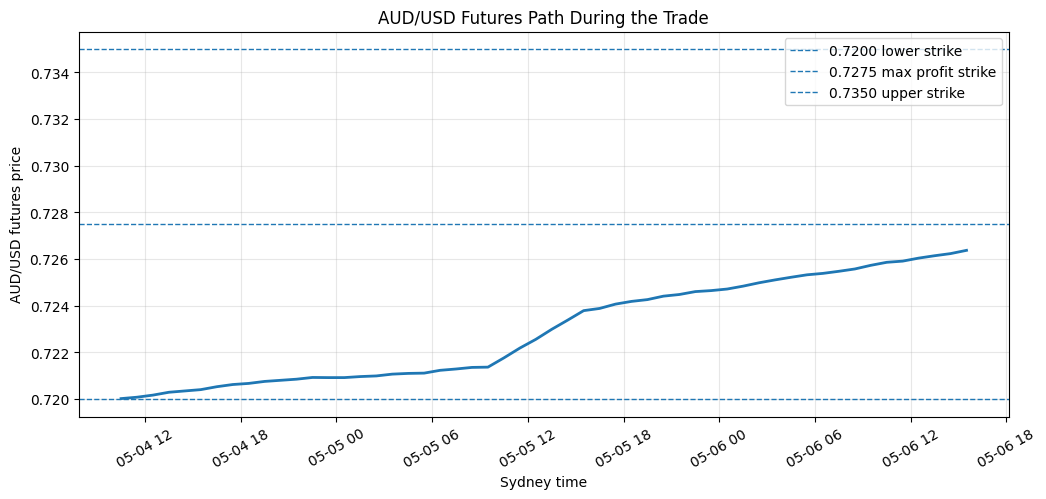

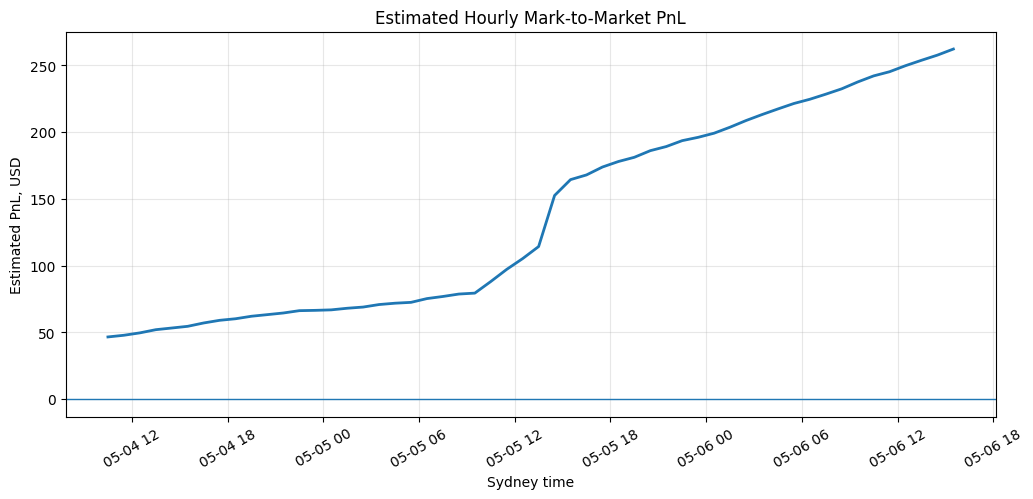

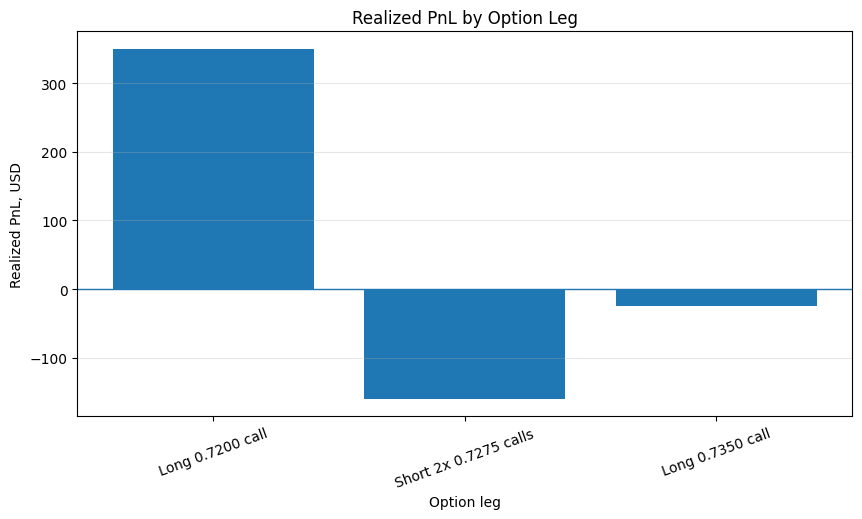

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(mtm["datetime_sydney"], mtm["audusd_futures"], linewidth=2)
plt.axhline(0.7200, linestyle="--", linewidth=1, label="0.7200 lower strike")
plt.axhline(0.7275, linestyle="--", linewidth=1, label="0.7275 max profit strike")
plt.axhline(0.7350, linestyle="--", linewidth=1, label="0.7350 upper strike")
plt.title("AUD/USD Futures Path During the Trade")
plt.xlabel("Sydney time")
plt.ylabel("AUD/USD futures price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(mtm["datetime_sydney"], mtm["estimated_total_pnl_usd"], linewidth=2)
plt.axhline(0, linewidth=1)
plt.title("Estimated Hourly Mark-to-Market PnL")
plt.xlabel("Sydney time")
plt.ylabel("Estimated PnL, USD")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.show()

leg_pnl = realized[["leg", "pnl_usd"]].copy()
plt.figure(figsize=(10, 5))
plt.bar(leg_pnl["leg"], leg_pnl["pnl_usd"])
plt.axhline(0, linewidth=1)
plt.title("Realized PnL by Option Leg")
plt.xlabel("Option leg")
plt.ylabel("Realized PnL, USD")
plt.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.show()


In [11]:
total_pnl = realized["pnl_usd"].sum()
net_debit = (legs["qty"] * legs["entry_price"] * CONTRACT_MULTIPLIER).sum()
max_intrinsic = (middle_K - lower_K) * CONTRACT_MULTIPLIER
max_profit = max_intrinsic - net_debit
max_loss = net_debit

performance_summary = pd.DataFrame({
    "Metric": [
        "Strategy",
        "Entry date",
        "Exit date",
        "Net debit paid, USD",
        "Maximum possible loss, USD",
        "Maximum possible profit at expiry, USD",
        "Realized PnL, USD",
        "Return on net debit",
        "Best estimated hourly PnL, USD",
        "Worst estimated hourly PnL, USD"
    ],
    "Value": [
        "Long 0.7200 / 0.7275 / 0.7350 AUD/USD call butterfly",
        ENTRY_TIME_SYDNEY.strftime("%d %b %Y, %H:%M Sydney"),
        EXIT_TIME_SYDNEY.strftime("%d %b %Y, %H:%M Sydney"),
        f"${net_debit:,.2f}",
        f"${max_loss:,.2f}",
        f"${max_profit:,.2f}",
        f"${total_pnl:,.2f}",
        f"{total_pnl / abs(net_debit):.2%}",
        f"${mtm['estimated_total_pnl_usd'].max():,.2f}",
        f"${mtm['estimated_total_pnl_usd'].min():,.2f}"
    ]
})

performance_summary


,Metric,Value
0,Strategy,Long 0.7200 / 0.7275 / 0.7350 AUD/USD call but...
1,Entry date,"04 May 2026, 10:30 Sydney"
2,Exit date,"06 May 2026, 15:30 Sydney"
3,"Net debit paid, USD",$130.00
4,"Maximum possible loss, USD",$130.00
5,"Maximum possible profit at expiry, USD",$620.00
6,"Realized PnL, USD",$165.00
7,Return on net debit,126.92%
8,"Best estimated hourly PnL, USD",$262.18
9,"Worst estimated hourly PnL, USD",$46.51
